In [2]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
import nltk, string, random, numpy, os
import matplotlib.pyplot as plt
from typing import List
os.makedirs('./results', exist_ok=True)
nltk.download('brown')
random.seed(42)
torch.manual_seed(42)
numpy.random.seed(42)

[nltk_data] Downloading package brown to /Users/Gileesa/nltk_data...
[nltk_data]   Package brown is already up-to-date!


### Introduction
In the warm-up of this assignment, we will see how Neural Networks (NN) handle natural language data.   
The warm-up focuses on a simple Multilayer Perceptron (MLP), also known as a fully connected Neural Network. The data we'll use is the first 5000 unique words of the Brown corpus.

### Dataset
To train the model, we will have to represent the input words to the model in some way. Since models solely work with numbers, the words will have to be converted into numerical form.  
For this assignment, we will focus on predicting individual words from the dataset given the input of the model. The input will be the target word split up into individual letters. To represent these individual letters we will give the model a vector of 26 positions (26 letters in the English alphabet). Initially, this vector is filled with zeros and for every occuring letter in the word we change the value to 1 in that position. For instance, in the word `apple', we have 1 a, 1 e, 1 l and 2 p. The vector will then represent the word as:  
```[1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,2,0,0,0,0,0,0,0,0,0,0]```  
You will have to implement this algorithm together with loading the Brown dataset and taking the first 5000 unique words. Implement a way to store the indexes of the unique words as a dictionary where the word is the key and the index is the value as well as the target list (which will be just the indexes of the words).

In [3]:
import numpy as np
class AlphaDataset(Dataset):
    def __init__(self) -> None:
        # Load the NLTK Brown corpus and store the first 5000 unique words of the corpus in self.data
        import nltk
        from collections import Counter, defaultdict
        nltk.download('brown')
        from nltk.corpus import brown

        words = brown.words()
        unique_words = []
        dic = {}
        for indx, word in enumerate(words):
            word = word.lower()
            if word not in unique_words and word.isalpha():
                dic[word] = len(unique_words)
                unique_words.append(word)
            if len(unique_words) >= 5000:
                break
        
        self.data = unique_words
        self.word_to_idx = dic # Convert the unique words to an index dictionary {word: index}
        self.targets = list(self.word_to_idx.values()) # Make these indexes the target values

    def __len__(self) -> int:
        # Torch requires the implementation of the length function to calculate the number of instances in the dataset. Find a way to implement this
        return len(self.data)

    def __getitem__(self, index):
        x = self.data[index]
        y = self.targets[index]

        x = x.lower()

        # Apply processing to turn the word (stored in x) into a numeric vector of 26 numbers, counting the occurences of the letters.
        # Example: apple would become [1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,2,0,0,0,0,0,0,0,0,0,0], counting 2 occurences for the letter p and zero for letters that do not occur.
        alphabet = 'abcdefghijklmnopqrstuvwxyz'
        alphabet_indices = {letter: idx for idx, letter in enumerate(alphabet)}
        
        word_vector = np.zeros(len(alphabet))
        for char in x:
            alphabet_index = alphabet_indices[char]
            word_vector[alphabet_index] += 1
            
        x = torch.tensor(word_vector, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.long)
        return x, y
    

### Multilayer Perceptron
In the following section, you will implement a MLP. The goal is to implement this MLP with 1 input layer, 2 hidden layers, and 1 output layer.
With PyTorch, the linear layer is most suitable for this. When you create a linear layer, you define the input and output size of the layer, effectively creating two linear neuron layers. This is useful to know since we only need to create 3 linear layer classes to have the 4 layers we want.
The hidden size is stored as a list where the first value will be 256 and the second value will be 512.

In [4]:
class MLP(nn.Module):
    def __init__(self, input_size: int, hidden_size: List[int], output_size: int) -> None:
        super().__init__()
        # Implement the neural network layers, the activation function is already defined
        self.input_layer = nn.Linear(input_size, hidden_size[0])
        self.hidden_layer = nn.Linear(hidden_size[0], hidden_size[1])
        self.output_layer = nn.Linear(hidden_size[1], output_size)
        self.activation = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # In the forward pass the model will calculate the gradients as well as the probabilities of the result occuring given its input.
        # Implement the missing layers

        x = self.input_layer(x) # Implement input layer
        x = self.activation(x)
        x = self.hidden_layer(x) # Implement hidden layer
        x = self.activation(x)
        x = self.output_layer(x) # Implement the output layer
        return x

### Setting up the hyperparameters
These are the hyperparameters used for the model, they define the layout of the model as well as the performance:
- batch_size, defines the number of instances the model sees at one time.
- learning_rate, defines the change rate of the gradient descent.
- input_size, the number of input neurons for the model, the number of letters in the alphabet
- hidden_size, the number of neurons in the hidden layer
- output_size, the number of neurons in the output layer, for us this is the number of unqiue words

In [5]:
batch_size = 8
learning_rate = 1e-5
input_size = 26
hidden_size = [256, 512]
output_size = 5000
device = 'cpu' # If you have an m1 macbook use: 'mbp', if you have an NVIDIA GPU use: 'cuda:0' else leave as is

Setting up the dataset

In [6]:
# Define the dataset and the dataloader
dataset = AlphaDataset()

# For the final evaluation of the model we will use 20% of the data for testing. Testing is only ever done after hyperparameter tuning.
# Split sizes (80% train, 20% test)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# To evaluate our model we want to take 10% of the dataset for validation, this is similar to the testset, rather this data we can use during hyperparameter tuning.
# The validation and test data is never trained on and is unseen data for the model, making it closer to a production setting.
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # Shuffling ensures the model does not overfit on ordering of the data.
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # This data does not need to be shuffled
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)  #T his data does not need to be shuffled

[nltk_data] Downloading package brown to /Users/Gileesa/nltk_data...
[nltk_data]   Package brown is already up-to-date!


### Preperation for training
Here we load the model into memory, apply it to the selected device and define the optimizer. The optimizer guides the model to the best possible state it can be in through Gradient descent.
Lastly, the loss function is defined, this defines how well the model performs, based on this number the model knows how it should change its weights.

In [7]:
model = MLP(input_size, hidden_size, output_size)
model.to(device) # Tell de model which accelerator to use (Macbook GPU, NVIDIA GPU or CPU)

# In Neural Networks optimizers handle the efficient training through gradient descent, we will use Adam
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)

# The loss function defines how well the model is performing, if the loss is low the model is rewarded, if it is high the model is punished.
# Since we are dealing with a classification task we will use Cross Entropy
loss_fn = nn.CrossEntropyLoss()

### Training
In the next block the training block is already defined. This is a standard way to train the model for 50 epochs (50 times it will see the dataset). Each time it does one epoch we also go over the validationset.

In [8]:
training_losses = []
validation_losses = []

for epoch in range(50): # Train for 50 epochs
    model.train() # Enforce model training
    for step, (x, y) in enumerate(train_loader):
        x = x.to(device)
        y = y.to(device)

        output = model(x)

        loss = loss_fn(output, y)

        training_losses.append(loss.item())
        print(loss.item(), end='\r')

        loss.backward() # Calculate gradients

        optimizer.step() # Reward the model
        optimizer.zero_grad() # Clean the gradients
    print('Training_loss:', loss.item())

    model.eval() # After every training epoch we want to see the model's performance on the validation data
    with torch.no_grad(): # In validation we dont need gradients so we tell torch to not calculate them
        total_val_loss = 0
        for step, (x, y) in enumerate(val_loader):
            x = x.to(device)
            y = y.to(device)

            output = model(x)

            loss = loss_fn(output, y)

            total_val_loss += loss.item()

        validation_losses.append(total_val_loss / len(val_dataset))
        print('Validation_loss:', validation_losses[-1])

Training_loss: 8.533098220825195
Validation_loss: 1.0698297357559203
Training_loss: 8.46747875213623
Validation_loss: 1.080580062866211
Training_loss: 8.311605453491211
Validation_loss: 1.0982918238639832
Training_loss: 8.251197814941406
Validation_loss: 1.128314151763916
Training_loss: 7.983473300933838
Validation_loss: 1.1727496790885925
Training_loss: 7.970165729522705
Validation_loss: 1.227899000644684
Training_loss: 7.916754722595215
Validation_loss: 1.2880531311035157
Training_loss: 7.763291358947754
Validation_loss: 1.3495013976097108
Training_loss: 7.631608486175537
Validation_loss: 1.4107525610923768
Training_loss: 7.309081554412842
Validation_loss: 1.4721529364585877
Training_loss: 7.424574851989746
Validation_loss: 1.5343357849121093
Training_loss: 7.48552131652832
Validation_loss: 1.5976466608047486
Training_loss: 7.1962151527404785
Validation_loss: 1.6628207278251648
Training_loss: 7.1928815841674805
Validation_loss: 1.7299792861938477
Training_loss: 7.009232997894287
Vali

### Writing
Below we can print the training statistics, the training loss should be going down while the validation loss should be going up. What does it mean that the validation loss increases?

If the validation loss increases, it means the model is performing worse on the validation set as training goes on. This could mean the model is being overfitted on the training data, meaning the training loss goes down while the validation loss goes up. Overfitting means that the model is memorizing the training data rather than learning to generalise.

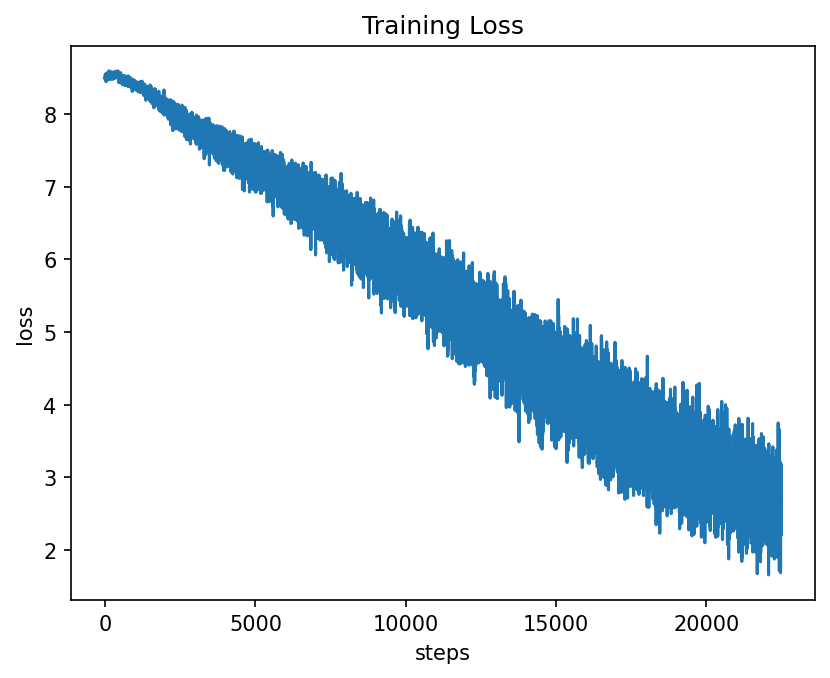

In [9]:
plt.rcParams['figure.dpi'] = 150
plt.plot(training_losses)
plt.xlabel('steps')
plt.ylabel('loss')
plt.title('Training Loss')
plt.savefig('./results/training_loss.png')

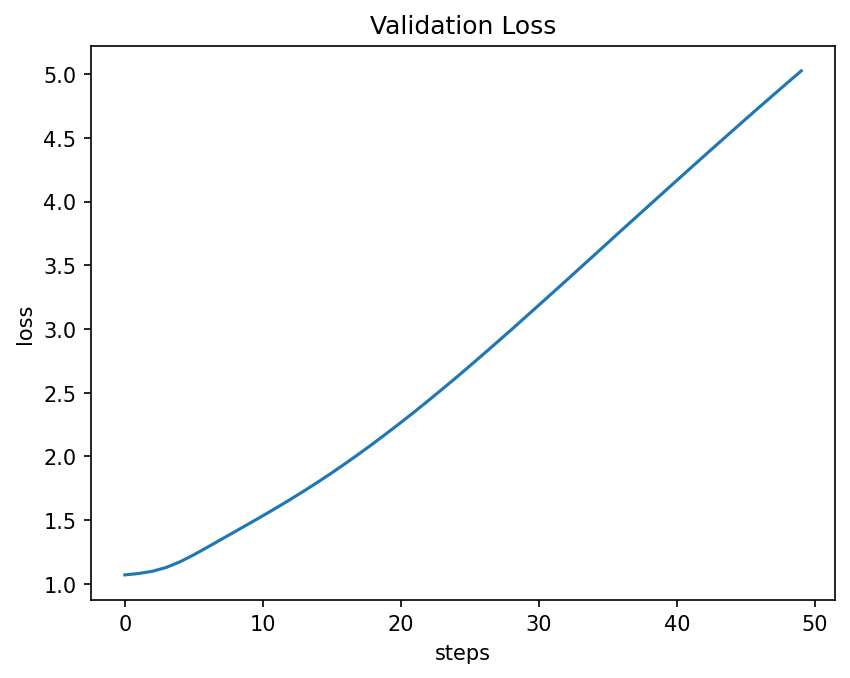

In [10]:
plt.plot(validation_losses)
plt.xlabel('steps')
plt.ylabel('loss')
plt.title('Validation Loss')
plt.savefig('./results/validation_loss.png')

### Writing
#### Below we want to analyze how the model functions based on the test data. What stands out from these results? Was the result correct? What is the main difference between the words?

The results show that the model performs quite poorly and the results are not correct. This is because it is hard to generalise from letter-count vectors to reconstructing words. The wrongly predicted words seem to have similar letter counts as the targets.

In [11]:
def get_n_words(dataset, n, model, ds, verbose = True):
    if n == -1:
        n = len(dataset)
    x = [dataset.__getitem__(i)[0] for i in range(n)]
    y = [dataset.__getitem__(i)[1] for i in range(n)]
    target_words = [{idx: word for word, idx in ds.word_to_idx.items()}[_.item()] for _ in y]
    out = [nn.functional.softmax(model(wrd)).argmax() for wrd in x]
    predicted_words = [{idx: word for word, idx in ds.word_to_idx.items()}[_.item()] for _ in out]
    width = max(len(word) for word in target_words) + 5
    if verbose:
        print('\n'.join([f'target: {t.ljust(width)} predicted: {p}' for t, p in zip(target_words, predicted_words)]))
    return target_words, predicted_words

_,_ = get_n_words(test_dataset, 10, model, dataset)

target: composition      predicted: motions
target: division         predicted: dividing
target: widely           predicted: middle
target: accepting        predicted: precinct
target: indemnity        predicted: imminent
target: polls            predicted: plays
target: succeeds         predicted: succeed
target: pardoned         predicted: dropped
target: honest           predicted: northwestern
target: poll             predicted: payroll


/var/folders/yq/hn587w994554wh5gg3rcqtlr0000gn/T/ipykernel_61960/2019737341.py:7: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  out = [nn.functional.softmax(model(wrd)).argmax() for wrd in x]


#### Why are some words incorrectly predicted?

It is hard to generalise letter count to words. The model's predicted words often have similar letter count as the targets, sometimes with a few extra letters and sometimes the same letter count, but different order. In other words, the letter count vector representation is too ambiguous to distinguish between words reliably.

### Code + Written
##### Research the Jaccard similarity metric for calculating the difference between the predicted word and the target word. Reference your sources and implement this metric in your code below. You can use the get_n_words function with n=-1 to get all the predicted and target words. Compare this method to similarity as measured with one of the word vector methods from A2, in writing and/or code.

The average Jaccard similarity of all target/prediction pairs was 0.569, meaning most pairs are quite similar according to this metric. The Jaccard similarity is based on how many characters in the target overlap with the prediction. The score is between 0 and 1, where 1 means exactly the same characters and 0 means no overlapping character.


For the GloVe cosine distance, the average score was 0.793, meaning most words are fairly dissimilar. Since we used a GloVe database that was pretrained on words from Wikipedia, 19 target/prediction pairs were skipped because they did not appear in GloVe's database. This makes the Jaccard similarity more robust to unknown words, thought the GloVe cosine distance gives more information regarding the similarity in meaning between words.

In [19]:
# Method 1

def get_J(predicted,target):
    similar_chars = float(len(list(set(predicted).intersection(target))))
    either_chars = float((len(predicted) + len(target)) - similar_chars)
    J = similar_chars/either_chars
    return J


targets,predictions = get_n_words(test_dataset, -1, model, dataset)

J_dict = {}
for target, prediction in zip(targets,predictions):
    J_dict[(target, prediction)] = get_J(prediction,target)

print(J_dict)
print('=' * 50)
print("AVERAGE J: ", sum(J_dict.values()) / len(J_dict))
print('=' * 50)

target: composition           predicted: motions
target: division              predicted: dividing
target: widely                predicted: middle
target: accepting             predicted: precinct
target: indemnity             predicted: imminent
target: polls                 predicted: plays
target: succeeds              predicted: succeed
target: pardoned              predicted: dropped
target: honest                predicted: northwestern
target: poll                  predicted: payroll
target: hastily               predicted: statistical
target: someplace             predicted: completes
target: prominently           predicted: implementation
target: loser                 predicted: followers
target: blume                 predicted: fumble
target: seeking               predicted: vexing
target: aroused               predicted: absorbed
target: audrey                predicted: ready
target: decided               predicted: decide
target: in                    predicted: inn
target: 

/var/folders/yq/hn587w994554wh5gg3rcqtlr0000gn/T/ipykernel_61960/2019737341.py:7: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  out = [nn.functional.softmax(model(wrd)).argmax() for wrd in x]


In [ ]:
# Method 2
import gensim.downloader as api
import numpy as np
wv_from_bin = api.load("glove-wiki-gigaword-200")
print("Loaded vocab size %i" % len(list(wv_from_bin.index_to_key)))

targets,predictions = get_n_words(test_dataset, -1, model, dataset)
results = []

for target, prediction in zip(targets,predictions):
    if target in wv_from_bin and prediction in wv_from_bin:
        word_syn = wv_from_bin.distance(target, prediction)
        results.append(word_syn)
    else:
        continue

print('=' * 50)
print('avg glove ', np.array(results).mean())
print('number of skipped pairs bc not in GloVe database: ', len(targets) - len(results))
print('=' * 50)

Loaded vocab size 400000
target: composition           predicted: motions
target: division              predicted: dividing
target: widely                predicted: middle
target: accepting             predicted: precinct
target: indemnity             predicted: imminent
target: polls                 predicted: plays
target: succeeds              predicted: succeed
target: pardoned              predicted: dropped
target: honest                predicted: northwestern
target: poll                  predicted: payroll
target: hastily               predicted: statistical
target: someplace             predicted: completes
target: prominently           predicted: implementation
target: loser                 predicted: followers
target: blume                 predicted: fumble
target: seeking               predicted: vexing
target: aroused               predicted: absorbed
target: audrey                predicted: ready
target: decided               predicted: decide
target: in                  

/var/folders/yq/hn587w994554wh5gg3rcqtlr0000gn/T/ipykernel_61960/2019737341.py:7: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  out = [nn.functional.softmax(model(wrd)).argmax() for wrd in x]
